***
# Project #3 Part 2: Sentiment Analysis of Reviews
### Felicia Faith Hangge
### 29 April 2025

#### Analyzing customer sentiment from over 60 Yelp reviews about Steakhouses in New Jersey using the Yelp Fusion API. My goal is to understand what influences customers to leave a good review or a bad review and see which sentiment (positive, negative, or neutral) is most frequent.
### Sample Question: How do customers rate their experience at New Jersey steakhouses, and what factors contribute most to positive or negative sentiment?

***

## 0.) Importing Libraries 
***

In [196]:
import requests
import json
import re
from textblob import TextBlob
from textblob.sentiments import NaiveBayesAnalyzer
from nltk.corpus import stopwords
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import nltk
nltk.download('punkt_tab')
nltk.download('movie_reviews')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/faitth/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package movie_reviews to
[nltk_data]     /Users/faitth/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/faitth/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## 1.) Collecting Reviews
***

#### API Setup

In [199]:
import yelpkeys
APIKEY = yelpkeys.api_key
headers = {'Authorization': 'Bearer %s' % yelpkeys.api_key,}


SEARCH_URL = "https://api.yelp.com/v3/businesses/search"
REVIEWS_URL = "https://api.yelp.com/v3/businesses/{id}/reviews"

#### Searching for Steakhouses and getting reviews

In [201]:
params = {
    "term": "steakhouse",
    "location": "New Jersey",
    "limit": 20
}

response = requests.get(SEARCH_URL, headers=HEADERS, params=params)
businesses = response.json().get("businesses", [])

all_reviews = []

for biz in businesses:
    biz_id = biz["id"]
    rev_response = requests.get(REVIEWS_URL.format(id=biz_id), headers=HEADERS)
    if rev_response.status_code == 200:
        for review in rev_response.json().get("reviews", []):
            all_reviews.append(review["text"])

print(f"Total reviews collected: {len(all_reviews)}")

Total reviews collected: 60


## 2.) Cleaning Data
***

In [203]:
def clean_text(text):
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    return text.lower()

cleaned_reviews = [clean_text(r) for r in all_reviews]
cleaned_reviews

['i had a perfectly seasoned porterhouse with steak fries cooked to perfection medium well servers are very friendly and happy to answer questions',
 'wow this place is a gem really awesome tasty and well cooked food and byob\n\ncame for dinner before going to see jo koy perform at prudential center this',
 'i order this at least once a week \nunmatched the bang for the buck on the oz bonein ribeye the flavor and cut are always top notch asparagus is',
 'the rodizio is always top notch  never disappointed the staff are always pleasant ensures that we are enjoying and makes us laugh\n\nrecommend going there',
 'ok so to start if you plan to have dinner here on the weekend a reservation is a must i tried  hrs inadvance and they had closed reservations as had',
 'what makes this place good was the amazing staff food other than the rodizio was just ok as we had two other seafood and pasta in cream sauce  go with the',
 'a paradise for music lovers and cocktails connoisseurs catch dj rol ev

## 3.) Sentiment Analysis  
***

#### TextBlob

In [206]:
default_sentiment = {"pos": 0, "neg": 0, "neu": 0}
for review in cleaned_reviews:
    polarity = TextBlob(review).sentiment.polarity
    if polarity > 0:
        default_sentiment["pos"] += 1
    elif polarity < 0:
        default_sentiment["neg"] += 1
    else:
        default_sentiment["neu"] += 1

#### NaiveBayesAnalyzer

In [208]:
nb_sentiment = {"pos": 0, "neg": 0, "neu": 0}
for review in cleaned_reviews:
    blob = TextBlob(review, analyzer=NaiveBayesAnalyzer())
    sentiment = blob.sentiment.classification
    nb_sentiment[sentiment] += 1

## 4.) Visualizations 
***

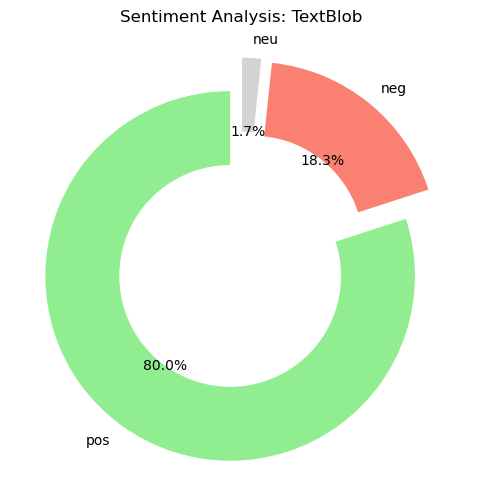

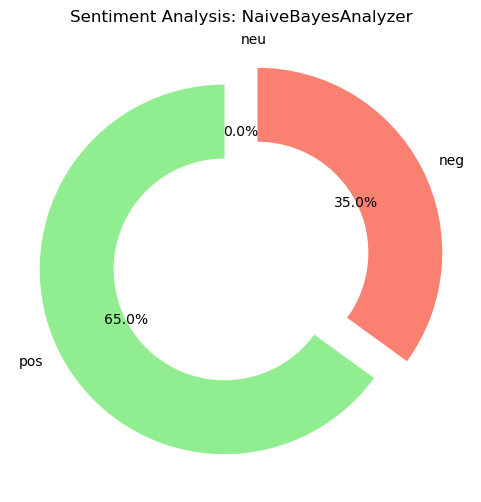

In [210]:
def plot_donut(data, title):
    labels = data.keys()
    sizes = data.values()
    explode = [0.1]*len(labels)
    colors = ['lightgreen', 'salmon', 'lightgray']

    plt.figure(figsize=(6, 6))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90,
            colors=colors, explode=explode, wedgeprops=dict(width=0.4))
    plt.title(title)
    plt.show()

plot_donut(default_sentiment, "Sentiment Analysis: TextBlob")
plot_donut(nb_sentiment, "Sentiment Analysis: NaiveBayesAnalyzer")

#### Removing Stop Words

In [211]:
stop_words = set(stopwords.words('english'))
filtered_words = " ".join(
    word for review in cleaned_reviews for word in review.split() if word not in stop_words
)

#### WordCloud

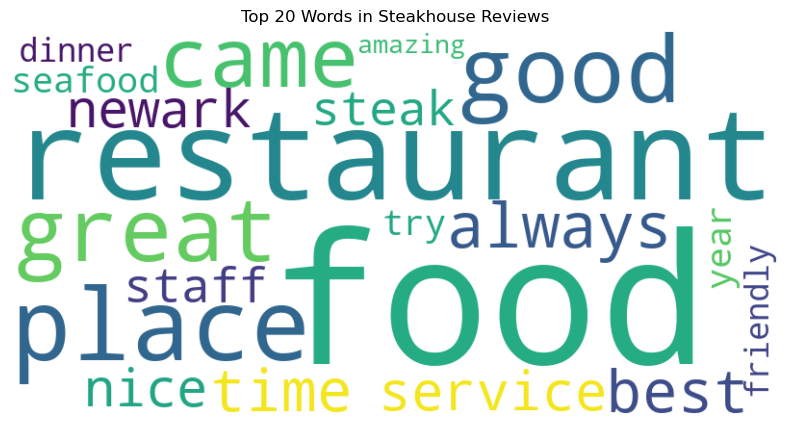

In [212]:
wordcloud = WordCloud(width=800, height=400, max_words=20, background_color='white').generate(filtered_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Top 20 Words in Steakhouse Reviews")
plt.show()

## 6.) Conclusion + Insights
***

#### This analysis of Yelp reviews for steakhouses in New Jersey showed that overall sentiment tends to be positive, especially when it comes to the quality of the food. Both the TextBlob and NaiveBayes analyzers showed that most reviewers were satisfied, although a few had some issues or remained neutral. 

#### The WordCloud showed us what is influencing people to write reviews the most, with words like “food" "steak", and "seafood" appearing frequently meaning most reviews are about the quality of their meals. Other words like like “friendly”, "service", and "staff" appear a lot as well, telling us that customer reviews are also influenced by the service provided to them. In conclusion, we can assume that most customers write reviews about the quality of their meals and the quality of the service they were given.

***